# Spam Email Detection

In [51]:
import re
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np
from collections import Counter
import pandas as pd
import nltk
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nltk.metrics.distance import edit_distance
import gensim.downloader as api
# from transformers import DistilBertTokenizer, DistilBertModel

from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
sns.set(style="whitegrid")

In [14]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /Users/rcpearl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rcpearl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/rcpearl/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rcpearl/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Dataset

In [3]:
# Load Dataset
df = pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.shape # Shape of data

(5572, 2)

In [9]:
df.isnull().sum() # Check null values

Category    0
Message     0
dtype: int64

In [ ]:
df.duplicated().any() # Check duplicate


In [42]:
df.drop_duplicates(inplace=True) # drop duplicate

In [ ]:
df.duplicated().any() # Check duplicate


np.False_

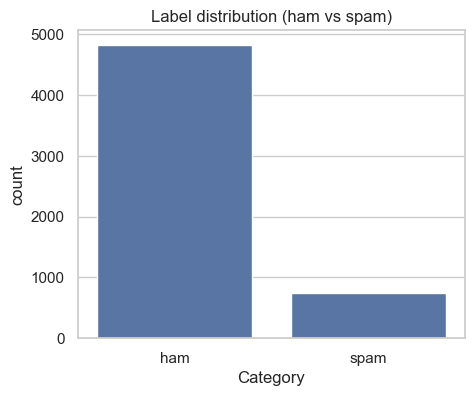

In [20]:
# data distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Category', data=df)
plt.title('Label distribution (ham vs spam)')
plt.show()

,char_count,word_count,avg_word_len
count,5572.000000,5572.000000,5572.000000
mean,80.368988,15.584171,5.173697
std,59.926946,11.406598,1.129126
min,2.000000,1.000000,2.000000
25%,35.750000,7.000000,4.571429
50%,61.000000,12.000000,5.000000
75%,122.000000,23.000000,5.583333
max,910.000000,171.000000,49.000000


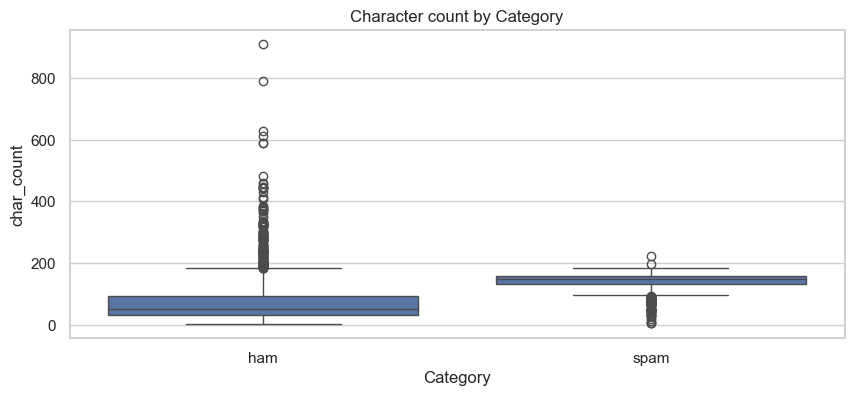

In [24]:
df['char_count'] = df['Message'].str.len()
df['word_count'] = df['Message'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
df['avg_word_len'] = df['char_count'] / df['word_count'].replace(0,1)
display(df[['char_count','word_count','avg_word_len']].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x='Category', y='char_count', data=df)
plt.title('Character count by Category')
plt.show()

In [ ]:
# top words
stop = set(stopwords.words('english'))
def top_n_words(series, n=20):
    c = Counter()
    for doc in series.dropna():
        for w in str(doc).lower().split():
            w = ''.join(ch for ch in w if ch.isalpha())
            if w and w not in stop:
                c[w]+=1
    return c.most_common(n)

top_ham = top_n_words(df[df.Category=='ham']['Message'])
top_spam = top_n_words(df[df.Category=='spam']['Message'])
print('Top ham words:', top_ham[:10])
print('Top spam words:', top_spam[:10])

# wordclouds
wc = WordCloud(width=600, height=300, background_color='white', stopwords=stop)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc.generate(' '.join(df[df.Category=='ham']['Message'].astype(str))))
plt.axis('off'); plt.title('Ham wordcloud')
plt.subplot(1,2,2)
plt.imshow(wc.generate(' '.join(df[df.Category=='spam']['Message'].astype(str))))
plt.axis('off'); plt.title('Spam wordcloud')
plt.show()

In [47]:
# Encode Category column 
le = LabelEncoder()
df['Category']=le.fit_transform(df['Category'])
df.head()

,Category,Message,clean_Message,char_count,word_count,avg_word_len
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,111,20,5.550000
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6,4.833333
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...,155,28,5.535714
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say,49,11,4.454545
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though,61,13,4.692308


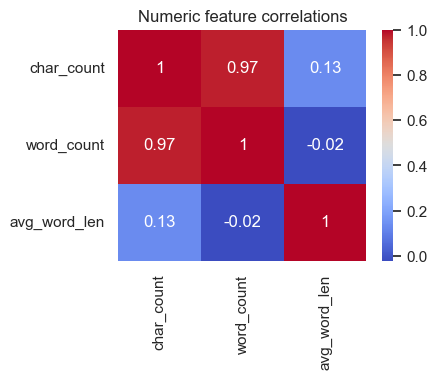

In [32]:
plt.figure(figsize=(4,3))
sns.heatmap(df[['char_count','word_count','avg_word_len']].corr(), annot=True, cmap='coolwarm')
plt.title('Numeric feature correlations')
plt.show()
df.to_csv('spam_with_features.csv', index=False)

# Preprocessing

In [68]:
# Lowercasing
def to_lowercase(text):
    return text.lower()

def normalize_repeated_chars(text): # regex
    return re.sub(r'(.)\1{2,}', r'\1', text)

#  Replace URLs with token (strong spam signal)
def replace_urls(text): # regex
    return re.sub(r'http\S+|www\.\S+', '__URL__', text)
#  Replace phone numbers with token (premium-rate = spam signal) ─
def replace_phones(text): # regex
    return re.sub(r'\b\d{7,}\b', '__PHONE__', text)
#  Replace currency amounts with token (£1000, $500 = spam) 
def replace_currency(text): # regex
    return re.sub(r'[£$€]\s?\d+', '__MONEY__', text)

# ── Step 6: SMS Slang Normalization (lookup dictionary) 
sms_slang = {
    'u'   : 'you',     'ur'  : 'your',    'r'   : 'are',
    'txt' : 'text',    '2'   : 'to',      '4'   : 'for',
    'gr8' : 'great',   'b4'  : 'before',  'ngl' : 'not gonna lie',
    'omg' : 'oh my god', 'lol': 'laugh',  'btw' : 'by the way',
    'w1n' : 'win',     'fr33': 'free',    'priz': 'prize',
    'wiin': 'win',     'urgnt':'urgent',  'cliam':'claim',
    'plz' : 'please',  'thx' : 'thanks',  'msg' : 'message',
    'mob' : 'mobile',  'tel' : 'telephone','num' : 'number',
    'cust': 'customer','info': 'information','yr' : 'year',
    'wk'  : 'week',    'wkly': 'weekly',  'mins': 'minutes',
    'da'  : 'the',     'dis' : 'this',    'dat' : 'that',
}

def normalize_sms_slang(text):
    return ' '.join(sms_slang.get(w, w) for w in text.split())
# Regular expression to remove HTML tags
def remove_html_tags(text): # regex
    return re.sub(r'<.*?>', '', text)

# Regular expression to remove punctuation and numbers
def remove_punctuation(text): # regex
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Tokenization
def tokenize_text(text):
    return word_tokenize(text)

# Stop word removal
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Stemming
stemmer = PorterStemmer()
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

# Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Full preprocessing pipeline
def preprocess_text(text):
    text = to_lowercase(text)
    text = normalize_repeated_chars(text)   # NEW: freeeeee → free
    text = replace_urls(text)               # NEW: URLs → __URL__
    text = replace_phones(text)             # NEW: phone numbers → __PHONE__
    text = replace_currency(text)           # NEW: £/$€ amounts → __MONEY__
    text = normalize_sms_slang(text) 
    text = remove_html_tags(text)
    text = remove_punctuation(text)         # FIXED: now keeps numbers
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

# ── Separate pipeline for BERT (no stopword removal, keep punctuation) ────
def preprocess_text_bert(text):
    """Lighter cleaning for contextual models — BERT needs full context."""
    text = to_lowercase(text)
    text = normalize_repeated_chars(text)
    text = replace_urls(text)
    text = replace_phones(text)
    text = replace_currency(text)
    text = normalize_sms_slang(text) 
    text = remove_html_tags(text)
    return text   # keep punctuation + stopwords for BERT

In [69]:
# Apply standard pipeline (for BoW / TF-IDF / fastText)
df['clean_Message'] = df['Message'].apply(preprocess_text)

# Apply BERT pipeline (for distilBERT contextual embeddings)
df['bert_Message'] = df['Message'].apply(preprocess_text_bert)

df[['Message', 'clean_Message', 'bert_Message']].head()

,Message,clean_Message,bert_Message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,"go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar joking wif oni,ok lar. joking wif you oni.
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts 2...,free entry in to a weekly comp to win fa cup f...
3,U dun say so early hor... U c already then say...,dun say early hor c already say,you dun say so early hor. you c already then say.
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though,"nah i don't think he goes to usf, he lives aro..."


In [70]:
# ── Before vs After comparison ───────────────────────────────────────────────
examples = [2, 5, 10]   # pick a spam and some ham rows

for idx in examples:
    label_map = {0: 'HAM', 1: 'SPAM'}
    label = label_map[df['Category'].iloc[idx]] 
    print(f'[{label}] Row {idx}')
    print(f'  ORIGINAL  : {df["Message"].iloc[idx]}')
    print(f'  CLEANED   : {df["clean_Message"].iloc[idx]}')
    print(f'  BERT-CLEAN: {df["bert_Message"].iloc[idx]}')
    print()

# Show token-level difference
orig_tokens  = df['Message'].str.split().explode()
clean_tokens = df['clean_Message'].str.split().explode()
print(f'Unique tokens BEFORE cleaning : {orig_tokens.nunique():,}')
print(f'Unique tokens AFTER  cleaning : {clean_tokens.nunique():,}')
print(f'Vocabulary reduction          : {(1 - clean_tokens.nunique()/orig_tokens.nunique())*100:.1f}%')

# Check special tokens are present
special = ['__URL__', '__PHONE__', '__MONEY__']
for tok in special:
    count = df['clean_Message'].str.contains(tok).sum()
    print(f'Messages containing {tok:12s}: {count}')

[SPAM] Row 2
  ORIGINAL  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  CLEANED   : free entry weekly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd text ratetcs apply 08452810075over18s
  BERT-CLEAN: free entry in to a weekly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std text rate)t&c's apply 08452810075over18's

[SPAM] Row 5
  ORIGINAL  : FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
  CLEANED   : freemsg hey darling 3 week word back id like fun still tb ok x std chgs send MONEY50 rcv
  BERT-CLEAN: freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! x std chgs to send, __MONEY__.50 to rcv

[HAM] Row 10
  ORIGINAL  : I'm gonna be home 

# Feature Extraction

In [ ]:
# NOTE: Edit distance works well for correcting genuine typos (e.g. 'recieve' → 'receive')
# For SMS data, it is less effective because SMS uses intentional abbreviations
# (e.g. 'txt', 'u', 'gr8') which are not misspellings — they are a different register.
# Edit distance is demonstrated here as a cleaning technique concept.
# all_words = ' '.join(df['clean_Message']).split()
# vocab = set(all_words)

# def correct_word(word, vocab, max_dist=2):
#     """Return closest vocab word if edit distance <= max_dist, else return original."""
#     if word in vocab:
#         return word
#     candidates = [
#         (edit_distance(word, v), v)
#         for v in vocab if abs(len(word) - len(v)) <= max_dist
#     ]
#     if not candidates:
#         return word
#     best_dist, best_word = min(candidates, key=lambda x: x[0])
#     return best_word if best_dist <= max_dist else word

# # Demo on intentionally misspelled spam-like words
# demo_words = ['fr33', 'wiin', 'priz', 'urgnt', 'cliam']
# print('Edit Distance Correction Demo:')
# for w in demo_words:
#     print(f'  {w:10s}  ->  {correct_word(w, vocab)}')

# # Apply to a sample (full dataset is slow; run in background or use multiprocessing)
# sample_corrected = df['clean_Message'][:200].apply(
#     lambda txt: ' '.join(correct_word(w, vocab) for w in txt.split())
# )
# print('\nBefore:', df['clean_Message'][2])
# print('After :', sample_corrected[2])

## 1. Set of Words (Binary Bag-of-Words)
Records *whether* a word appears (1 or 0) rather than its frequency.  
Effective for SMS spam because trigger words matter more than repetition count.

Set-of-Words matrix shape : (5572, 3000)
Example row (first 20 dims): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]  ...


/var/folders/yq/f9wv9np53s98yzc2_k3sxh880000gn/T/ipykernel_58704/1047280184.py:14: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  spam_presence.plot(kind='bar', ax=axes[0], color='salmon',    title='Top words in SPAM (presence rate)')
/var/folders/yq/f9wv9np53s98yzc2_k3sxh880000gn/T/ipykernel_58704/1047280184.py:15: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ham_presence.plot( kind='bar', ax=axes[1], color='steelblue', title='Top words in HAM (presence rate)')


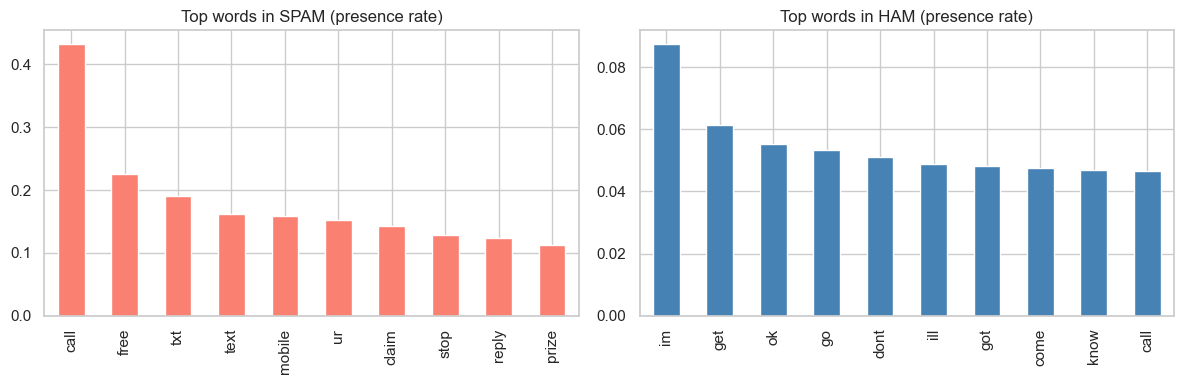

In [34]:
sow_vectorizer = CountVectorizer(binary=True, max_features=3000)
X_sow = sow_vectorizer.fit_transform(df['clean_Message'])

print(f'Set-of-Words matrix shape : {X_sow.shape}')
print(f'Example row (first 20 dims): {X_sow[0].toarray()[0][:20]}  ...')

sow_df = pd.DataFrame(X_sow.toarray(), columns=sow_vectorizer.get_feature_names_out())
sow_df['Category'] = df['Category'].values

spam_presence = sow_df[sow_df.Category=='spam'].drop(columns='Category').mean().sort_values(ascending=False).head(10)
ham_presence  = sow_df[sow_df.Category=='ham'].drop(columns='Category').mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spam_presence.plot(kind='bar', ax=axes[0], color='salmon',    title='Top words in SPAM (presence rate)')
ham_presence.plot( kind='bar', ax=axes[1], color='steelblue', title='Top words in HAM (presence rate)')
plt.tight_layout(); plt.show()

In [31]:
# TF‑IDF top features by class
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
X = tfidf.fit_transform(df['Message'].astype(str))
tfidf_df = pd.DataFrame(X.todense(), columns=tfidf.get_feature_names_out())
tfidf_df['Category'] = df['Category'].values

spam_top = tfidf_df[tfidf_df.Category=='spam'].drop(columns='Category').mean().sort_values(ascending=False).head(20)
ham_top  = tfidf_df[tfidf_df.Category=='ham'].drop(columns='Category').mean().sort_values(ascending=False).head(20)
print('Top TF-IDF (spam):\n', spam_top.head(10))
print('Top TF-IDF (ham):\n', ham_top.head(10))

Top TF-IDF (spam):
 free      0.052703
txt       0.038766
mobile    0.034575
text      0.033072
claim     0.032626
stop      0.032247
prize     0.028721
ur        0.028716
reply     0.028465
www       0.027210
dtype: float64
Top TF-IDF (ham):
 ok      0.023199
ll      0.017964
come    0.016105
gt      0.015599
just    0.015582
lt      0.015503
good    0.014343
like    0.014131
got     0.014103
know    0.013785
dtype: float64


In [30]:
# top n-grams
def top_ngrams(corpus, ngram_range=(1,1), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(w, sum_words[0, idx]) for w, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

print('Top bigrams in spam:', top_ngrams(df[df.Category=='spam'].Message, ngram_range=(2,2), n=10))
print('Top bigrams in ham:', top_ngrams(df[df.Category=='ham'].Message, ngram_range=(2,2), n=10))

Top bigrams in spam: [('po box', np.int64(27)), ('1000 cash', np.int64(23)), ('prize guaranteed', np.int64(22)), ('send stop', np.int64(21)), ('national rate', np.int64(20)), ('selected receive', np.int64(19)), ('await collection', np.int64(19)), ('urgent mobile', np.int64(18)), ('land line', np.int64(18)), ('customer service', np.int64(17))]
Top bigrams in ham: [('lt gt', np.int64(276)), ('ll later', np.int64(42)), ('let know', np.int64(40)), ('sorry ll', np.int64(39)), ('good morning', np.int64(32)), ('don know', np.int64(24)), ('lt decimal', np.int64(23)), ('decimal gt', np.int64(23)), ('new year', np.int64(23)), ('pls send', np.int64(22))]
